UPLOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset_PIR.csv to Dataset_PIR.csv


IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np

LOAD DAN CEK DATASET

In [ ]:
df = pd.read_csv('Dataset_PIR.csv')
df.head()

,Tanggal,Interval Mulai,Interval Selesai,t (interval),count,durasi aktif,lag1,lag2,lag3,lag4,lag5,lag6,avg30,avg60,delta1,label
0,2026-05-14 00:00:00,2026-05-14 12:45:37,2026-05-14 12:55:37,1,11,94.701,0,0,0,0,0,0,11.0,11.00,0,tinggi
1,2026-05-14 00:00:00,2026-05-14 12:55:48,2026-05-14 13:05:37,2,6,44.100,11,0,0,0,0,0,8.5,8.50,-5,tinggi
2,2026-05-14 00:00:00,2026-05-14 13:05:43,2026-05-14 13:15:37,3,4,35.000,6,11,0,0,0,0,7.0,7.00,-2,sedang
3,2026-05-14 00:00:00,2026-05-14 13:15:44,2026-05-14 13:25:37,4,2,15.500,4,6,11,0,0,0,4.0,5.75,-2,sedang
4,2026-05-14 00:00:00,2026-05-14 13:25:45,2026-05-14 13:35:37,5,3,26.300,2,4,6,11,0,0,3.0,5.20,1,sedang


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tanggal           1487 non-null   object 
 1   Interval Mulai    1487 non-null   object 
 2   Interval Selesai  1487 non-null   object 
 3   t (interval)      1487 non-null   int64  
 4   count             1487 non-null   int64  
 5   durasi aktif      1487 non-null   float64
 6   lag1              1487 non-null   int64  
 7   lag2              1487 non-null   int64  
 8   lag3              1487 non-null   int64  
 9   lag4              1487 non-null   int64  
 10  lag5              1487 non-null   int64  
 11  lag6              1487 non-null   int64  
 12  avg30             1487 non-null   float64
 13  avg60             1487 non-null   float64
 14  delta1            1487 non-null   int64  
 15  label             1487 non-null   object 
dtypes: float64(3), int64(9), object(4)
memory 

,0
Tanggal,0
Interval Mulai,0
Interval Selesai,0
t (interval),0
count,0
durasi aktif,0
lag1,0
lag2,0
lag3,0
lag4,0


In [ ]:
df = df.dropna()

MEMISAHKAN FITUR DAN LABEL

In [ ]:
X = df[['count', 'durasi aktif', 'lag1', 'lag2', 'lag3',
        'lag4', 'lag5', 'lag6',
        'avg30', 'avg60', 'delta1']]

y = df['label']

ENCODING LABEL

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

SPLIT DATA (TRAIN&TEST)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

TRAINING MODEL RF KLASIFIKASI

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

EVALUASI MODEL

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.9966442953020134
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       179
           1       0.98      1.00      0.99        41
           2       1.00      0.99      0.99        78

    accuracy                           1.00       298
   macro avg       0.99      1.00      0.99       298
weighted avg       1.00      1.00      1.00       298



CEK OVERFITTING

In [ ]:
# CEK OVERFITTING - bandingkan akurasi train vs test
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
selisih   = acc_train - acc_test

print(f"Akurasi Train : {acc_train:.4f}")
print(f"Akurasi Test  : {acc_test:.4f}")
print(f"Selisih       : {selisih:.4f}")
print()

if selisih < 0.02:
    print("Kesimpulan: TIDAK overfitting — model generalisasi dengan baik")
elif selisih < 0.05:
    print("Kesimpulan: OVERFITTING RINGAN — masih bisa diterima")
else:
    print("Kesimpulan: OVERFITTING — perlu diatasi")

Akurasi Train : 1.0000
Akurasi Test  : 0.9966
Selisih       : 0.0034

Kesimpulan: TIDAK overfitting — model generalisasi dengan baik


CONFUSION MATRIX

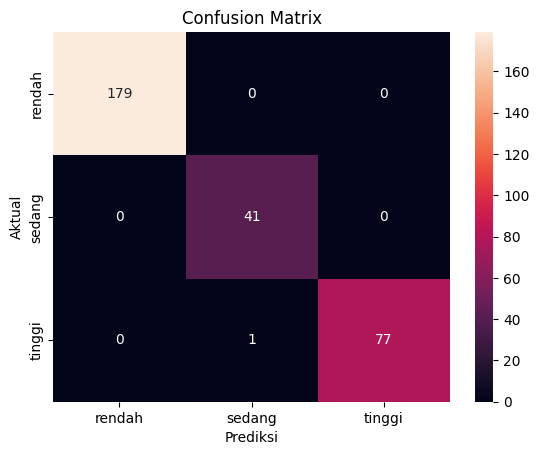

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

SIMPAN MODEL KLASIFIKASI

In [ ]:
import joblib

joblib.dump(model, 'model_rf_klasifikasitikus.pkl')
files.download('model_rf_klasifikasitikus.pkl')
print('Model berhasil disimpan dan didownload!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model berhasil disimpan dan didownload!
